# AIO880 Test 2: Calculus
You have 1 hour to complete 2 of the following questions, by next week's class you should have completed the entire test with 100% accuracy.

## Question 1: 

For the following parts we will consider the following 3d surface:

$$\left(x^2 - 1\right)^2\left(y^2 - 1\right)^2 + \left(y^2 - 1\right)^2\left(z^2 - 1\right)^2 + \left(z^2 - 1\right)^2\left(x^2 - 1\right)^2 = 0.08$$


### 1a. Plot this surface

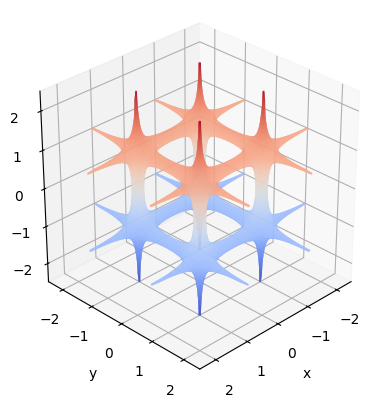

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes

res = 150
low = -2.5
high = 2.5

xvals = np.linspace(low, high, res)
yvals = np.linspace(low, high, res)
zvals = np.linspace(low, high, res)
step = xvals[1] - xvals[0]

xg, yg, zg = np.meshgrid(xvals, yvals, zvals, indexing="ij")

xterm = (xg**2 - 1)**2
yterm = (yg**2 - 1)**2
zterm = (zg**2 - 1)**2

field = xterm * yterm + yterm * zterm + zterm * xterm - 0.08

verts, faces, norms, vals = marching_cubes(field, level=0, spacing=(step, step, step))
verts = verts + low

fig = plt.figure()
axis = fig.add_subplot(projection="3d")

axis.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], cmap="coolwarm")

axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_zlabel("z")

axis.set_xlim(low, high)
axis.set_ylim(low, high)
axis.set_zlim(low, high)

axis.set_box_aspect((1, 1, 1))
axis.view_init(elev=30, azim=45)

plt.show()

### 1b. Calculate the gradient of this surface

Our original equation:
$$
f(x,y,z) = (x^2-1)^2(y^2-1)^2 + (y-1)^2(z^2-1)^2+(z^2-1)^2(x^2-1)^2
$$
using the chain rule:
$$
\frac{d}{dx}(x^2-1)^2 = 2(x^2-1)\cdot\frac{d}{dx}(x^2-1) = 2(x^2-1)(2x) = 4x(x^2-1)
$$
so for 
$$
\frac{\partial f}{\partial x}
$$
we calculate for the first term, second term, and third term. we can ignore the second term, since theres no x in it. that essentially makes it a constant.
\
first term:
$$
((x^2-1)^2(y^2-1)^2)
$$
$$
\frac{\partial f}{\partial x}((x^2-1)^2(y^2-1)^2)=4x(x^2-1)(y^2-1)^2
$$
$$
\frac{\partial f}{\partial x}((z^2-1)^2(x^2-1)^2)) = (z^2-1)^24x(x^2-1)
$$
this simplies out to:
$$
\frac{\partial f}{\partial x} = 4x(x^2-1)((y^2-1)^2+(z^2-1)^2))
$$
Using symmetry:
$$
\frac{\partial f}{\partial y} = 4y(y^2-1)((x^2-1)^2+(z^2-1)^2))
$$
$$
\frac{\partial f}{\partial z} = 4z(z^2-1)((y^2-1)^2+(x^2-1)^2))
$$
The gradient becomes:
$$
\nabla F = \begin{bmatrix} 4x(x^2-1)\left[(y^2-1)^2+(z^2-1)^2\right] \\[6pt] 4y(y^2-1)\left[(z^2-1)^2+(x^2-1)^2\right] \\[6pt] 4z(z^2-1)\left[(x^2-1)^2+(y^2-1)^2\right] \end{bmatrix}
$$

### 1c. Plot the plane tangent to the surface at the point lying on it where x + y + z is maximized
Plot both the surface and the tangent plane, just giving the coordinates where x + y + z is maximized will give partial credit

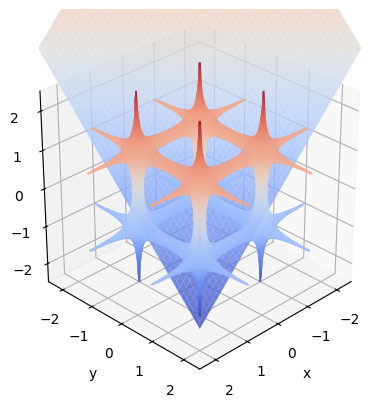

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes
res = 150
low = -2.5
high = 2.5
xvals = np.linspace(low, high, res)
yvals = np.linspace(low, high, res)
zvals = np.linspace(low, high, res)
step = xvals[1] - xvals[0]
xg, yg, zg = np.meshgrid(xvals, yvals, zvals, indexing="ij")

xterm = (xg**2 - 1)**2
yterm = (yg**2 - 1)**2
zterm = (zg**2 - 1)**2
field = xterm * yterm + yterm * zterm + zterm * xterm - 0.08
verts, faces, norms, vals = marching_cubes(field, level=0, spacing=(step, step, step))
verts = verts + low
t = np.sqrt(1 + (0.08 / 3)**0.25)
c = 3 * t
xp, yp = np.meshgrid(xvals, yvals)
zp = c - xp - yp
fig = plt.figure()
axis = fig.add_subplot(projection="3d")
axis.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], cmap="coolwarm")
axis.plot_surface(xp, yp, zp, cmap="coolwarm", alpha=0.8)
axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_zlabel("z")
axis.set_xlim(low, high)
axis.set_ylim(low, high)
axis.set_zlim(low, high)
axis.set_box_aspect((1, 1, 1))
axis.view_init(elev=30, azim=45)

plt.show()

## Question 2: 
Recall the taylor series approximation of a 1d function using some anchor point a:
$$f(x) \approx \sum_{i=0}^{n} \frac{f^{(i)}(a)}{i!}(x-a)^i$$
Where $f^{(i)}$ is the i-th derivative of the function f.

### 2a. Prove that the limit of the taylor series approximation of $e^x$ approaches $e^x$ as n approaches $\infty$

we can first define a mclaurin sum (just a taylor sum with a = 0) for $e^x$:
$$
S_n(x) = \sum_{k=0}^n \frac{x^k}{k!}
$$
for every term, we can differentiate down using power rule (since the derivative of $e^x $ is itself, this is trivially easy)
so:
$$
S_n'(x) = \sum_{k=1}^n \frac{x^{k-1}}{(k-1)!} = S_{n-1}(x)
$$
for every power of $x$ above $x^0$ becomes non-existient at $x=0$, which leaves us with:
$$
S_n(0) = 1
$$
for every n
\
now we can define some function as an infinite series:
$$
\phi(x) = \lim_{n\to\infty} S_n(x)
$$
our eventual goal is to prove that this new function is equal to $e^x$
from this, we can assume:
$$
\phi'(x) = \phi(x), \qquad \phi(0) = 1
$$
now we use some function $\psi$ to create a ratio:
$$
\psi(x) = \phi(x)e^{-x}
$$
we can use this to differentiate from our originial $\phi$ equation $\phi = \phi$ (phi prime, but i cant type it for some reason)
Using these facts, we have:
$$
\psi'(x) = \phi'(x)e^{-x} - \phi(x)e^{-x} = \phi(x)e^{-x} - \phi(x)e^{-x} = 0
$$
since it equals zero everywhere (no matter the x value), we can find the value easily using $x = 0$.

so we have:
$$
\psi(0) = \phi(0)e^0 = 1 
$$
then:
$$
\psi(x) =1
$$
Since $\psi = \phi(x)e^{-x}=1$ for every single x:
simple math gives us:
$$
\phi(x) = e^x
$$
and so:
$$
\sum_{k=0}^\infty \frac{x^k}{k!} = \phi(x) = e^x
$$

### 2b. Find an infinite series which approaches $\frac{e^x}{cos(x)}$

We can write this equation as:
$$
\frac{e^x}{cos(x)} = e^x*sec(x)
$$
We can now write the infinite series as a product of two infinite series. We already have $e^x$, so now we can do $sec(x)$
The infinite series for $cos(x)$:
$$
\cos(x) = \sum_{m=0}^\infty \frac{(-1)^m x^{2m}}{(2m)!}
$$
Writing out $\frac{1}{cos(x)}$:
$$
\sec x = 1 + \frac{x^2}{2} + \frac{5x^4}{24} + \dots
$$
We can multiply the two series together and find a pattern:
$$
e^x \cdot \sec x = \left(1 + x + \frac{x^2}{2} + \frac{x^3}{6} + \dots\right)\left(1 + \frac{x^2}{2} + \dots\right)
$$
i lwk dont know where to go from here...

### Bonus: Give a formula for a taylor series approximation of a multidimensional function

## Question 3:
For this question, recall the Self-Attention formula:
$$Att(Q,K,V) = Softmax(\frac{Q \cdot K^T}{\sqrt{d_k}})\cdot V$$
Where:
$$Q = E \cdot W_Q$$
$$K = E \cdot W_K$$
$$V = E \cdot W_V$$

We will also consider a loss function:
$$L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$$

### 3a: Find the gradient of out loss with respect to the weights

$$
S = \frac{QK^T}{\sqrt{d_k}}, \qquad A = \text{softmax}(S), \qquad Att = AV
$$

The loss is defined with y hat as attention:
so loss becomes:
$$
L = \frac12(y-Att)^2
$$
so the gradient for attention the output is:
$$
\frac{\partial L}{\partial Att} = Att - y
$$
Since $Att = AV$, we get
$$
\frac{\partial L}{\partial V} = A^T(Att-y), \qquad \frac{\partial L}{\partial A} = (Att-y)V^T
$$
now we pass the gradient through softmax using:
$$
G_s = \frac{\partial L}{\partial S}
$$
this is just the softmax derivative applied to $(Att-y)V^T$, so we redefine $G_s$ as
$$
G_s = \text{backsoftmax}\left((Att-y)V^T\right)
$$
Since $S = \dfrac{QK^T}{\sqrt{d_k}}$, the gradients for $Q$ and $K$ will be:
$$
\frac{\partial L}{\partial Q} = \frac{1}{\sqrt{d_k}}G_sK, \qquad \frac{\partial L}{\partial K} = \frac{1}{\sqrt{d_k}}G_s^TQ
$$
since $Q=EW_Q$, $K=EW_K$, $V=EW_V$, the final gradient with respect to the weights are
$$
\frac{\partial L}{\partial W_Q} = \frac{1}{\sqrt{d_k}}E^TG_sK
$$
$$
\frac{\partial L}{\partial W_K} = \frac{1}{\sqrt{d_k}}E^TG_s^TQ
$$
$$
\frac{\partial L}{\partial W_V} = E^TA^T(Att-y)
$$
where $G_s = \text{backsoftmax}\left((Att-y)V^T\right)$.
where $G_s$ is defined as:
$G_s = \frac{\partial L}{\partial S}$

I used google on this problem for reference. (this took a while)

### 3b. Find the Derivative of Loss w.r.t. E

$$
\frac{\partial L(y,Att)}{\partial E} = (y-Att)\left(\left(SM\left(\frac{Q\cdot K^T}{\sqrt{d_k}}\right)V\right)^TW_Q^T + \frac{V^TK}{\sqrt{d_k}}W_K^T + \frac{V^TQ}{\sqrt{d_k}}W_V^T\right)
$$